## 1. Before You Begin

Real deployments don't get clean audio. This notebook measures **how fast
MAI-Transcribe-1.5 degrades as noise increases**, using a controlled sweep
instead of anecdotes:

1. Take one clean recording and mix it with several noise categories — café,
   traffic, music, and white noise
2. Scale each mixture to a target **signal-to-noise ratio** — 20, 10, 5, and 0 dB
3. Score every transcript against a human-verified reference with **WER** and
   **CER**, and record processing time
4. Plot WER against SNR, one line per noise category

It is standalone — run it without
[mai-transcribe-1.5.ipynb](mai-transcribe-1.5.ipynb), though that notebook covers
the API basics first.

**Prerequisites**

1. A Microsoft Foundry (AI Services / Speech) resource in a region where LLM
   Speech is available — see
   [Speech service regions](https://learn.microsoft.com/en-us/azure/ai-services/speech-service/regions?tabs=llmspeech).
   See [models/quickstart/](../../../quickstart/README.md) for first-time setup.
2. The environment variables listed in section 2.
3. **A verified reference transcript** for the clean clip, in
   [`data/reference/transcripts.json`](data/reference/transcripts.json). Section 4
   explains how to produce one. Without it there is no ground truth, so WER and
   CER can't be computed — the sweep still reports latency.

**Cost and runtime.** The default grid is 4 noise categories × 4 SNR levels + 1
clean control = **17 calls** over a ~50 s clip ≈ 14 minutes of audio ≈ **$0.09**
at $0.36 / audio hour. Each call is billed, so trim `SNR_LEVELS` or
`NOISE_CATEGORIES` while you iterate.

> **Signal-to-noise ratio (SNR)** in decibels is
> $10 \log_{10}(P_{speech} / P_{noise})$. 20 dB is speech comfortably above the
> noise floor; 0 dB is speech and noise at equal power — roughly a loud café.


## 2. Set up your environment

Same connection settings as the main capsule notebook: the transcription client
talks to the **resource** endpoint, not the project endpoint, so the path suffix
is stripped from `MICROSOFT_FOUNDRY_ENDPOINT`. Set `AZURE_SPEECH_ENDPOINT` to
override when your Speech resource is separate from your Foundry project.

Extra packages for this notebook:

| Package | Used for |
|---|---|
| `soundfile` | Decoding MP3/WAV/FLAC to NumPy arrays and writing mixtures |
| `numpy` | Noise synthesis and SNR scaling |
| `jiwer` | Word Error Rate and Character Error Rate |
| `pandas` / `matplotlib` | Results table and the WER-vs-SNR plot |


In [1]:
%pip install azure-ai-transcription azure-identity python-dotenv soundfile numpy jiwer pandas matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
import os
from pathlib import Path
from urllib.parse import urlparse

from azure.core.credentials import AzureKeyCredential

foundry_endpoint = os.environ.get("MICROSOFT_FOUNDRY_ENDPOINT")
speech_endpoint = os.environ.get("AZURE_SPEECH_ENDPOINT")

if not (speech_endpoint or foundry_endpoint):
    raise EnvironmentError(
        "Set MICROSOFT_FOUNDRY_ENDPOINT (or AZURE_SPEECH_ENDPOINT) before continuing."
    )

if not speech_endpoint:
    parsed = urlparse(foundry_endpoint)
    speech_endpoint = f"{parsed.scheme}://{parsed.netloc}"

API_KEY = os.environ.get("AZURE_SPEECH_API_KEY") or os.environ.get("MICROSOFT_FOUNDRY_API_KEY")
if API_KEY:
    CREDENTIAL = AzureKeyCredential(API_KEY)
    auth = "API key"
else:
    from azure.identity import DefaultAzureCredential

    CREDENTIAL = DefaultAzureCredential()
    auth = "Entra ID (DefaultAzureCredential)"

ENDPOINT = speech_endpoint
MODEL = os.environ.get("MAI_TRANSCRIBE_MODEL", "mai-transcribe-1.5")

DATA_DIR = Path("data")
NOISE_DIR = DATA_DIR / "noise"
REFERENCE_FILE = DATA_DIR / "reference" / "transcripts.json"
OUT_DIR = Path("output")
MIX_DIR = OUT_DIR / "mixed"
NOISE_DIR.mkdir(exist_ok=True)
MIX_DIR.mkdir(parents=True, exist_ok=True)

# The cleanest recording in data/ — the sweep adds noise to this one.
CLEAN_CLIP = DATA_DIR / "normal - on call agent building.mp3"
LOCALE = "en-US"  # full BCP-47 tag — bare "en" is rejected as an unsupported locale
SNR_LEVELS = [20, 10, 5, 0]

if not CLEAN_CLIP.exists():
    raise FileNotFoundError(f"Expected {CLEAN_CLIP.resolve()}")

print(f"Endpoint   : {ENDPOINT}")
print(f"Model      : {MODEL}")
print(f"Auth       : {auth}")
print(f"Clean clip : {CLEAN_CLIP.name}")
print(f"SNR levels : {SNR_LEVELS} dB")
print(f"Mixtures   : {MIX_DIR.resolve()}")


Endpoint   : https://bethanycheum-resource.services.ai.azure.com
Model      : mai-transcribe-1.5
Auth       : Entra ID (DefaultAzureCredential)
Clean clip : normal - on call agent building.mp3
SNR levels : [20, 10, 5, 0] dB
Mixtures   : /workspaces/model-releases/models/microsoft-ai/mai-transcribe-1.5/2026-06-02/output/mixed


## 3. Configure the client

The benchmark calls the model dozens of times, so the wrapper below never
raises: a failed call becomes a row with an `error` string, and the sweep
continues. Every row carries wall-clock latency and the **real-time factor**
(`latency ÷ audio duration`) — the number that tells you whether a pipeline can
keep up with live audio.


In [4]:
import time

from azure.ai.transcription import TranscriptionClient
from azure.ai.transcription.models import (
    EnhancedModeProperties,
    TranscriptionContent,
    TranscriptionOptions,
)

client = TranscriptionClient(endpoint=ENDPOINT, credential=CREDENTIAL)


def transcribe(audio_path, *, locales: list[str] | None = None, style: str | None = None):
    """Transcribe one file with MAI-Transcribe-1.5 and return the result object."""
    # Passing task/target_language/prompt makes the SDK inject enabled=True, which the
    # service rejects alongside model. Construct empty and set the keys directly.
    enhanced = EnhancedModeProperties()
    enhanced["model"] = MODEL
    if style:
        enhanced["transcribeStyle"] = style

    opts: dict = {"enhanced_mode": enhanced}
    if locales:
        opts["locales"] = locales

    with open(audio_path, "rb") as audio:
        content = TranscriptionContent(definition=TranscriptionOptions(**opts), audio=audio)
        return client.transcribe(content)


def run(audio_path, **kwargs) -> dict:
    """Transcribe and return a record row — never raises, so a batch can finish."""
    record = {
        "transcript": "",
        "audio_seconds": None,
        "latency_seconds": None,
        "rtf": None,
        "mean_confidence": None,
        "error": None,
    }

    started = time.perf_counter()
    try:
        result = transcribe(audio_path, **kwargs)
    except Exception as exc:  # one bad clip must not abort the sweep
        record["error"] = f"{type(exc).__name__}: {exc}"
        record["latency_seconds"] = round(time.perf_counter() - started, 2)
        return record

    latency = time.perf_counter() - started
    audio_seconds = result.duration_milliseconds / 1000
    confidences = [p.confidence for p in result.phrases if p.confidence is not None]
    record["transcript"] = result.combined_phrases[0].text
    record["audio_seconds"] = round(audio_seconds, 2)
    record["latency_seconds"] = round(latency, 2)
    record["rtf"] = round(latency / audio_seconds, 3) if audio_seconds else None
    record["mean_confidence"] = round(sum(confidences) / len(confidences), 3) if confidences else None
    return record


## 4. Curate the ground-truth reference

WER and CER are only as trustworthy as the reference you score against.
[`data/reference/transcripts.json`](data/reference/transcripts.json) maps each
clip name to its verified transcript and ships **empty** — the audio is yours to
listen to, and no one else's transcript is authoritative.

To fill it in:

1. Run `bootstrap_reference()` below. It transcribes the clean clip once and
   writes `data/reference/transcripts.draft.json`.
2. **Listen to the clip and correct the draft by hand.** Model output scored
   against itself gives WER ≈ 0 and measures nothing.
3. Paste the corrected text into `transcripts.json` under the clip name.

Normalization matters as much as the words: WER is computed after lowercasing,
stripping punctuation, and collapsing whitespace — applied identically to
reference and hypothesis — so casing and comma placement never inflate the score.
Write digits the way you expect the model to emit them.

If the reference is still empty, the sweep runs anyway and reports latency, with
WER and CER left as `NaN`.


In [5]:
import json

import jiwer

WORD_NORM = jiwer.Compose(
    [
        jiwer.ToLowerCase(),
        jiwer.RemovePunctuation(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ReduceToListOfListOfWords(),
    ]
)
CHAR_NORM = jiwer.Compose(
    [
        jiwer.ToLowerCase(),
        jiwer.RemovePunctuation(),
        jiwer.RemoveMultipleSpaces(),
        jiwer.Strip(),
        jiwer.ReduceToListOfListOfChars(),
    ]
)


def load_references() -> dict[str, str]:
    if not REFERENCE_FILE.exists():
        return {}
    return json.loads(REFERENCE_FILE.read_text(encoding="utf-8")).get("transcripts", {})


def score(reference: str, hypothesis: str) -> tuple[float | None, float | None]:
    """Return (WER, CER), or (None, None) when there is no reference to score against."""
    if not reference.strip() or not hypothesis.strip():
        return None, None
    wer = jiwer.wer(reference, hypothesis, reference_transform=WORD_NORM, hypothesis_transform=WORD_NORM)
    cer = jiwer.cer(reference, hypothesis, reference_transform=CHAR_NORM, hypothesis_transform=CHAR_NORM)
    return round(wer, 4), round(cer, 4)


def bootstrap_reference(clip=CLEAN_CLIP) -> Path:
    """Transcribe one clip and write an UNVERIFIED draft reference for hand-correction."""
    record = run(clip, locales=[LOCALE])
    if record["error"]:
        raise RuntimeError(record["error"])
    draft_path = REFERENCE_FILE.with_name("transcripts.draft.json")
    draft = json.loads(draft_path.read_text(encoding="utf-8")) if draft_path.exists() else {}
    draft[clip.name] = record["transcript"]
    draft_path.write_text(json.dumps(draft, indent=2, ensure_ascii=False), encoding="utf-8")
    print(f"Draft written → {draft_path}\nCorrect it by ear, then copy into {REFERENCE_FILE.name}.")
    return draft_path


REFERENCES = load_references()
REFERENCE = REFERENCES.get(CLEAN_CLIP.name, "")

if REFERENCE.strip():
    print(f"Reference loaded for {CLEAN_CLIP.name} ({len(REFERENCE.split())} words)")
else:
    print(
        f"No reference yet for {CLEAN_CLIP.name}.\n"
        f"WER/CER will be NaN. Run bootstrap_reference() to start a draft, "
        f"correct it by ear, then fill in {REFERENCE_FILE}."
    )

# bootstrap_reference()

No reference yet for normal - on call agent building.mp3.
WER/CER will be NaN. Run bootstrap_reference() to start a draft, correct it by ear, then fill in data/reference/transcripts.json.


## 5. Mix noise at controlled SNR levels

To attribute a WER change to noise, everything else has to stay fixed: same
speech, same words, same speaker — only the noise floor moves.

`mix_at_snr()` scales the noise so the mixture hits a target SNR exactly:

```
scale = sqrt( P_speech / (P_noise · 10^(SNR/10)) )
mixed = speech + scale · noise
```

Four noise categories are **synthesised**, so the notebook runs anywhere without
shipping recordings:

| Category | Signal | Stands in for |
|---|---|---|
| `cafe` | Pink noise (−3 dB / octave) amplitude-modulated at ~3 Hz | Crowd babble at a syllabic rate |
| `traffic` | Brown noise (−6 dB / octave) | Road rumble, HVAC, wind |
| `music` | Sustained four-note chord with slow vibrato | Background or hold music — tonal, not broadband |
| `white` | Flat spectrum | Hiss, electrical and fan noise |

Music is the interesting one: it masks narrow frequency bands rather than the
whole spectrum, so it usually costs less accuracy than broadband noise at the
same SNR — until it overlaps the speech formants.

For **real café, traffic, or music** recordings, drop WAV/MP3/FLAC files into
`data/noise/` — anything found there is picked up automatically and labelled by
file name. Real recordings are the honest test; synthetic noise is the
reproducible one.

Everything is resampled to 16 kHz mono, which is what speech recognition
consumes, and mixtures are written as 16-bit WAV to `output/mixed/`.


In [6]:
import numpy as np
import soundfile as sf
from IPython.display import Audio, display

TARGET_SR = 16_000
RNG = np.random.default_rng(20260602)


def load_mono(path, target_sr: int = TARGET_SR) -> np.ndarray:
    """Decode WAV/MP3/FLAC to mono float64 at target_sr."""
    data, sr = sf.read(path, dtype="float64", always_2d=True)
    mono = data.mean(axis=1)
    if sr != target_sr:
        n = int(round(len(mono) * target_sr / sr))
        mono = np.interp(np.linspace(0, len(mono) - 1, n), np.arange(len(mono)), mono)
    return mono


def synth_noise(kind: str, n: int, sr: int = TARGET_SR) -> np.ndarray:
    white = RNG.standard_normal(n)
    t = np.arange(n) / sr
    if kind == "white":
        out = white
    elif kind == "cafe":
        # 1/sqrt(f) shaping gives pink (-3 dB/octave); the ~3 Hz envelope mimics
        # the syllabic rhythm of crowd babble.
        spectrum = np.fft.rfft(white)
        freqs = np.fft.rfftfreq(n, d=1.0)
        scaling = np.ones_like(freqs)
        scaling[1:] = 1.0 / np.sqrt(freqs[1:])
        pink = np.fft.irfft(spectrum * scaling, n=n)
        out = pink * (0.7 + 0.3 * np.sin(2 * np.pi * 3.0 * t))
    elif kind == "traffic":
        out = np.cumsum(white)  # brown noise, -6 dB/octave rumble
    elif kind == "music":
        chord = sum(
            np.sin(2 * np.pi * f * t + RNG.uniform(0, 2 * np.pi))
            for f in (110.0, 138.59, 164.81, 220.0)
        )
        out = chord * (0.85 + 0.15 * np.sin(2 * np.pi * 0.5 * t))
    else:
        raise ValueError(f"Unknown noise kind: {kind}")
    out = out - out.mean()
    return out / (np.max(np.abs(out)) or 1.0)


def mix_at_snr(speech: np.ndarray, noise: np.ndarray, snr_db: float) -> np.ndarray:
    """Scale noise to hit an exact SNR against speech, then guard against clipping."""
    if len(noise) < len(speech):
        noise = np.tile(noise, int(np.ceil(len(speech) / len(noise))))
    noise = noise[: len(speech)]

    speech_power = float(np.mean(speech**2))
    noise_power = float(np.mean(noise**2))
    if noise_power == 0:
        raise ValueError("Noise source is silent")

    scale = np.sqrt(speech_power / (noise_power * 10 ** (snr_db / 10)))
    mixed = speech + scale * noise
    peak = float(np.max(np.abs(mixed)))
    return mixed / peak * 0.99 if peak > 1.0 else mixed


def measured_snr(speech: np.ndarray, mixed: np.ndarray) -> float:
    residual = mixed[: len(speech)] - speech
    return float(10 * np.log10(np.mean(speech**2) / np.mean(residual**2)))


speech = load_mono(CLEAN_CLIP)
print(f"Clean speech: {len(speech) / TARGET_SR:.1f}s @ {TARGET_SR} Hz mono")

NOISE_CATEGORIES: dict[str, np.ndarray] = {
    kind: synth_noise(kind, len(speech)) for kind in ("cafe", "traffic", "music", "white")
}

real_noise = sorted(p for p in NOISE_DIR.iterdir() if p.suffix.lower() in (".wav", ".mp3", ".flac"))
for path in real_noise:
    NOISE_CATEGORIES[path.stem] = load_mono(path)
print(f"Noise categories: {list(NOISE_CATEGORIES)}")
if not real_noise:
    print(f"(drop real café / traffic / music recordings into {NOISE_DIR}/ to add more categories)")

# Write one WAV per (category, SNR); the clean control keeps the same pipeline.
clean_wav = MIX_DIR / "clean.wav"
sf.write(clean_wav, speech, TARGET_SR, subtype="PCM_16")

mixtures: list[dict] = [{"category": "clean", "snr_db": None, "path": clean_wav}]
for category, noise in NOISE_CATEGORIES.items():
    for snr_db in SNR_LEVELS:
        mixed = mix_at_snr(speech, noise, snr_db)
        path = MIX_DIR / f"{category}_{snr_db}dB.wav"
        sf.write(path, mixed, TARGET_SR, subtype="PCM_16")
        mixtures.append(
            {
                "category": category,
                "snr_db": snr_db,
                "path": path,
                "measured_snr_db": round(measured_snr(speech, mixed), 2),
            }
        )

print(f"\n{len(mixtures)} files in {MIX_DIR} ({len(mixtures)} API calls ahead)")
print("Listen to the hardest mixture:")
display(Audio(filename=str(MIX_DIR / f"cafe_{min(SNR_LEVELS)}dB.wav")))


Clean speech: 49.8s @ 16000 Hz mono
Noise categories: ['cafe', 'traffic', 'music', 'white']
(drop real café / traffic / music recordings into data/noise/ to add more categories)

17 files in output/mixed (17 API calls ahead)
Listen to the hardest mixture:


## 6. Run the benchmark

One call per mixture, scored against the reference. Each row records:

| Column | Meaning |
|---|---|
| `wer` / `cer` | Word and character error rate, 0.0 is perfect, > 1.0 is possible when the model inserts words |
| `latency_seconds` / `rtf` | Processing time and latency ÷ audio duration |
| `mean_confidence` | Mean per-phrase confidence returned by the service |
| `error` | Exception text if the call failed; the sweep continues either way |

The clean control at the top of the table is your floor — every noisy row should
be read as a delta from it, not as an absolute. Results land in
`output/noise_benchmark.csv`.


In [7]:
import pandas as pd

rows: list[dict] = []

for item in mixtures:
    label = item["category"] if item["snr_db"] is None else f"{item['category']} @ {item['snr_db']} dB"
    print(f"→ {label} ... ", end="", flush=True)

    record = run(item["path"], locales=[LOCALE])
    wer, cer = score(REFERENCE, record["transcript"])

    rows.append(
        {
            "category": item["category"],
            "snr_db": item["snr_db"],
            "measured_snr_db": item.get("measured_snr_db"),
            "wer": wer,
            "cer": cer,
            "latency_seconds": record["latency_seconds"],
            "rtf": record["rtf"],
            "mean_confidence": record["mean_confidence"],
            "transcript": record["transcript"],
            "error": record["error"],
        }
    )
    print(record["error"] or (f"WER {wer:.3f}" if wer is not None else "no reference"))

benchmark = pd.DataFrame(rows)
benchmark.to_csv(OUT_DIR / "noise_benchmark.csv", index=False)

display(
    benchmark[
        ["category", "snr_db", "measured_snr_db", "wer", "cer", "latency_seconds", "rtf", "mean_confidence"]
    ]
)
print(f"\nSaved → {OUT_DIR / 'noise_benchmark.csv'}")

→ clean ... 

no reference
→ cafe @ 20 dB ... no reference
→ cafe @ 10 dB ... no reference
→ cafe @ 5 dB ... no reference
→ cafe @ 0 dB ... no reference
→ traffic @ 20 dB ... no reference
→ traffic @ 10 dB ... no reference
→ traffic @ 5 dB ... no reference
→ traffic @ 0 dB ... no reference
→ music @ 20 dB ... no reference
→ music @ 10 dB ... no reference
→ music @ 5 dB ... no reference
→ music @ 0 dB ... no reference
→ white @ 20 dB ... no reference
→ white @ 10 dB ... no reference
→ white @ 5 dB ... no reference
→ white @ 0 dB ... no reference


,category,snr_db,measured_snr_db,wer,cer,latency_seconds,rtf,mean_confidence
0,clean,NaN,NaN,None,None,3.79,0.076,0.802
1,cafe,20.0,20.0,None,None,2.30,0.046,0.781
2,cafe,10.0,10.0,None,None,2.32,0.047,0.739
3,cafe,5.0,5.0,None,None,2.33,0.047,0.709
4,cafe,0.0,0.0,None,None,2.24,0.045,0.574
5,traffic,20.0,20.0,None,None,2.13,0.043,0.810
6,traffic,10.0,10.0,None,None,2.11,0.042,0.802
7,traffic,5.0,5.0,None,None,2.11,0.042,0.783
8,traffic,0.0,-0.0,None,None,2.85,0.057,0.789
9,music,20.0,20.0,None,None,2.51,0.050,0.794



Saved → output/noise_benchmark.csv


## 7. Plot WER against SNR

A table of numbers hides the shape of the degradation; a curve shows it. Read
the plot for two things:

- **Where the knee is.** Recognition usually holds flat down to some SNR and
  then falls off a cliff. That knee is the noise floor your deployment must stay
  above — and the threshold to alarm on.
- **Which category hurts most at the same SNR.** Equal SNR does not mean equal
  damage: broadband noise masking the speech band costs far more accuracy than
  low-frequency rumble at the same power.

The dashed horizontal line is the clean-audio WER — the best this model can do
on this recording.


No WER to plot — fill in data/reference/transcripts.json first.
Falling back to processing time, which is measurable without a reference.


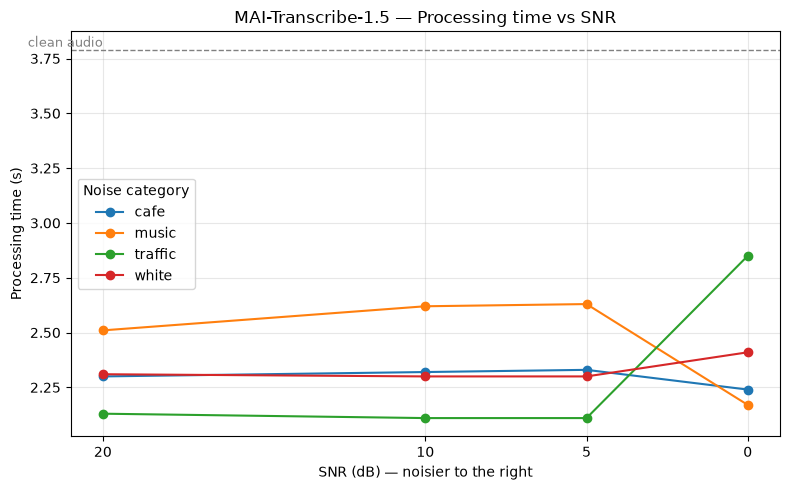

Saved → output/wer_vs_snr.png


In [8]:
import matplotlib.pyplot as plt

noisy = benchmark[benchmark["snr_db"].notna()]
clean_row = benchmark[benchmark["category"] == "clean"].iloc[0]

if noisy["wer"].isna().all():
    print(
        "No WER to plot — fill in data/reference/transcripts.json first.\n"
        "Falling back to processing time, which is measurable without a reference."
    )
    metric, ylabel, title = "latency_seconds", "Processing time (s)", "Processing time vs SNR"
else:
    metric, ylabel, title = "wer", "Word error rate", "Word error rate vs SNR"

fig, ax = plt.subplots(figsize=(8, 5))
for category, group in noisy.groupby("category"):
    group = group.sort_values("snr_db", ascending=False)
    ax.plot(group["snr_db"], group[metric], marker="o", label=category)

if clean_row[metric] is not None and not pd.isna(clean_row[metric]):
    ax.axhline(clean_row[metric], linestyle="--", color="gray", linewidth=1)
    ax.text(
        max(SNR_LEVELS),
        clean_row[metric],
        " clean audio",
        va="bottom",
        ha="right",
        color="gray",
        fontsize=9,
    )

ax.invert_xaxis()  # left-to-right = easy-to-hard
ax.set_xlabel("SNR (dB) — noisier to the right")
ax.set_ylabel(ylabel)
ax.set_title(f"MAI-Transcribe-1.5 — {title}")
ax.set_xticks(SNR_LEVELS)
ax.grid(alpha=0.3)
ax.legend(title="Noise category")
fig.tight_layout()

plot_path = OUT_DIR / "wer_vs_snr.png"
fig.savefig(plot_path, dpi=150)
plt.show()
print(f"Saved → {plot_path}")

## 9. Summary

You built a repeatable noise-robustness harness for MAI-Transcribe-1.5:

- Mixed one clean recording with café, traffic, music, and white noise at 20,
  10, 5, and 0 dB SNR
- Scored every mixture with WER and CER against a hand-verified reference
- Plotted WER against SNR per noise category to expose the knee

**Caveats:** WER requires a human-verified reference — model output scored
against itself measures nothing. Synthetic noise is a proxy; real environment
recordings are the honest test.

**Next:** [mai-transcribe-1.5.ipynb](mai-transcribe-1.5.ipynb) covers baseline
transcription, transcribe styles, and phrase-list biasing.

## 10. Your Turn

Try extending this benchmark with your own data and scenarios:

1. **Add real-world noise** — drop WAV/MP3/FLAC recordings into `data/noise/`
   (e.g. office HVAC, street traffic, crowd chatter). Re-run sections 5–6 and
   compare against the synthetic baselines.
2. **Fine-tune the SNR grid** — add intermediate levels (e.g. 15, 12, 8 dB) to
   `SNR_LEVELS` and re-run to locate the exact knee where accuracy degrades for
   your noise type.
3. **Benchmark additional clips** — place new audio in `data/`, add verified
   transcripts to `data/reference/transcripts.json`, and run section 6 to see
   how different speakers, accents, or recording conditions affect WER.
4. **Add recovery levers** — re-run the sweep with `transcribeStyle="verbatim"`
   or a `phraseList` to measure whether either lever recovers accuracy under
   noise (see the main notebook for the biasing API).
5. **Compare against MAI-Transcribe-1** — swap `MODEL` to `mai-transcribe-1` and
   re-run to quantify how much the newer model gains under noise.